📝 Περιγραφή

Πρόβλημα:
Μια βιομηχανική μονάδα παράγει μεταλλικά εξαρτήματα. Κάθε εξάρτημα περνά από δύο αισθητήρες μέτρησης (π.χ. δονήσεις & θερμοκρασία ή άξονες αναλυτή laser).
Με βάση τις δύο αυτές μετρήσεις πρέπει να ταξινομήσουμε το εξάρτημα ως:

Κλάση 0: Κανονικό / εντός προδιαγραφών

Κλάση 1: Ελαττωματικό / εκτός προδιαγραφών

Τι σημαίνουν οι δύο διαστάσεις:

Feature 1: Απόκλιση από την αναμενόμενη γεωμετρική συμμετρία (π.χ. laser profile deviation)

Feature 2: Επίπεδο δόνησης κατά τον έλεγχο ποιότητας

Στην πράξη τα “ελαττωματικά” εξαρτήματα τείνουν να εμφανίζουν διαφορετικό μοτίβο στη σχέση αυτών των δύο μεγεθών — συχνά με μη γραμμικό τρόπο — κάτι που φαίνεται καθαρά στο dataset.

Στόχος του μοντέλου:
Να μάθει αυτό το μη γραμμικό όριο απόφασης και να ταξινομεί σωστά νέα εξαρτήματα.

## Bagging (Bootstrap Aggregating)

Το Bagging, ή αλλιώς Bootstrap Aggregating, είναι μια τεχνική Ensemble Learning που χρησιμοποιείται για τη βελτίωση της σταθερότητας και της ακρίβειας αλγορίθμων μηχανικής μάθησης που πάσχουν από υψηλό variance (π.χ. Decision Trees).

**Πώς λειτουργεί:**

1.  **Δημιουργία Bootstrap Samples:** Από το αρχικό σύνολο δεδομένων εκπαίδευσης, δημιουργούνται πολλαπλά υποσύνολα (bootstrap samples) με δειγματοληψία με επανατοποθέτηση (sampling with replacement). Κάθε υποσύνολο έχει το ίδιο μέγεθος με το αρχικό dataset εκπαίδευσης, αλλά περιέχει διαφορετικούς συνδυασμούς των αρχικών δεδομένων. Ορισμένα δεδομένα μπορεί να εμφανίζονται πολλές φορές σε ένα υποσύνολο, ενώ άλλα καθόλου.
2.  **Εκπαίδευση Πολλαπλών Μοντέλων:** Ένας αλγόριθμος βάσης (π.χ. ένα Decision Tree) εκπαιδεύεται ανεξάρτητα σε κάθε ένα από αυτά τα bootstrap samples.
3.  **Συνδυασμός Προβλέψεων:**
    *   **Για προβλήματα Ταξινόμησης (Classification):** Οι προβλέψεις από όλα τα επιμέρους μοντέλα συνδυάζονται μέσω πλειοψηφικής ψήφου (majority voting). Η κλάση που προβλέπεται από τα περισσότερα μοντέλα είναι η τελική πρόβλεψη.
    *   **Για προβλήματα Παλινδρόμησης (Regression):** Οι προβλέψεις συνδυάζονται συνήθως λαμβάνοντας τον μέσο όρο των προβλέψεων των επιμέρους μοντέλων.

**Οφέλη του Bagging:**

*   **Μείωση του Variance:** Το Bagging μειώνει το variance των προβλέψεων μειώνοντας την επίδραση της τυχαιότητας στα δεδομένα εκπαίδευσης. Επειδή κάθε μοντέλο εκπαιδεύεται σε ένα ελαφρώς διαφορετικό υποσύνολο δεδομένων, τα λάθη τους τείνουν να αντισταθμίζονται.
*   **Αποτροπή Overfitting:** Βοηθά στην αποτροπή του overfitting σε σχέση με ένα μόνο μοντέλο βάσης, καθώς ο συνδυασμός πολλών μοντέλων παράγει ένα πιο γενικευμένο αποτέλεσμα.
*   **Αυξημένη Σταθερότητα:** Το τελικό μοντέλο είναι πιο σταθερό και λιγότερο ευαίσθητο σε μικρές αλλαγές στα δεδομένα εκπαίδευσης.

**Παραδείγματα:**

Ο Random Forest είναι μια επέκταση του Bagging που χρησιμοποιεί Decision Trees ως αλγόριθμους βάσης και εισάγει ένα επιπλέον στοιχείο τυχαιότητας στην επιλογή των χαρακτηριστικών κατά τη δημιουργία κάθε δέντρου.

,Feature 1,Feature 2,Target
0,1.006769,-0.500118,1
1,1.831027,0.214122,1
2,0.146651,1.151115,0
3,-0.194047,1.268410,0
4,-0.688850,0.769947,0
5,-0.044720,0.043324,1
6,0.871580,-0.517092,1
7,-1.225946,0.277261,0
8,1.521089,-0.289117,1
9,0.603490,0.894650,0


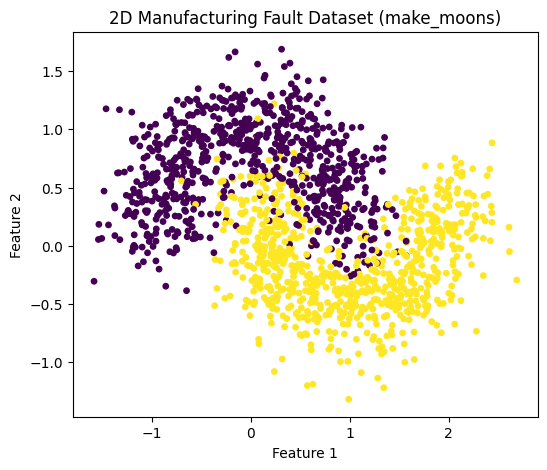

In [1]:
# ============================================
# 1. ΕΙΣΑΓΩΓΗ ΒΙΒΛΙΟΘΗΚΩΝ & ΔΗΜΙΟΥΡΓΙΑ DATASET
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_curve, auc
)
from matplotlib.colors import ListedColormap

# Δημιουργούμε το dataset:
# Ένα "μη πραγματικό" dataset, αλλά περιγράφεται εύκολα σαν πραγματικό βιομηχανικό πρόβλημα.
X, y = make_moons(n_samples=1500, noise=0.25, random_state=42)


# Μετατροπή του X σε DataFrame
df_combined = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

# Προσθήκη του y ως νέας στήλης
df_combined['Target'] = y

# Εμφάνιση των πρώτων 10 καταγραφών
display(df_combined.head(10))

# Διαχωρισμός σε train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Οπτικοποίηση dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=15)
plt.title("2D Manufacturing Fault Dataset (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [ ]:
# ============================================
# 2. ΕΚΠΑΙΔΕΥΣΗ ΑΠΛΟΥ DECISION TREE
# ============================================

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9222222222222223

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       234
           1       0.94      0.89      0.92       216

    accuracy                           0.92       450
   macro avg       0.92      0.92      0.92       450
weighted avg       0.92      0.92      0.92       450


Confusion Matrix:
 [[222  12]
 [ 23 193]]


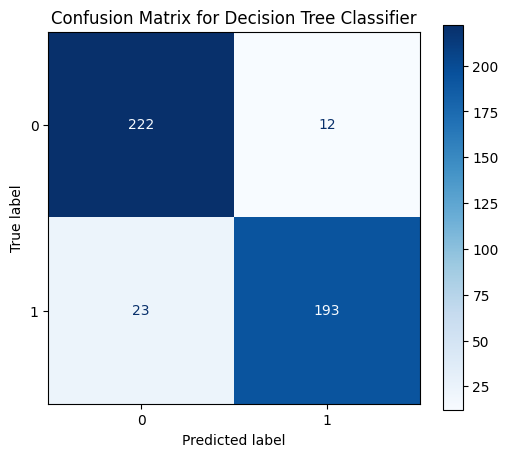

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Δημιουργία και εμφάνιση του Confusion Matrix για το Decision Tree
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Decision Tree Classifier")
plt.show()

In [ ]:
# ============================================
# 3. BAGGING ΜΕ ΔΙΑΦΟΡΑ ΠΛΗΘΗ ΑΠΟ ΔΕΝΤΡΑ
# ============================================

n_trees_list = [1, 5, 10, 20, 50, 100, 200, 300]
accuracies = []

for n in n_trees_list:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(f"Trees={n}  →  Accuracy={acc:.4f}")

Trees=1  →  Accuracy=0.9156
Trees=5  →  Accuracy=0.9311
Trees=10  →  Accuracy=0.9267
Trees=20  →  Accuracy=0.9333
Trees=50  →  Accuracy=0.9311
Trees=100  →  Accuracy=0.9444
Trees=200  →  Accuracy=0.9422
Trees=300  →  Accuracy=0.9422


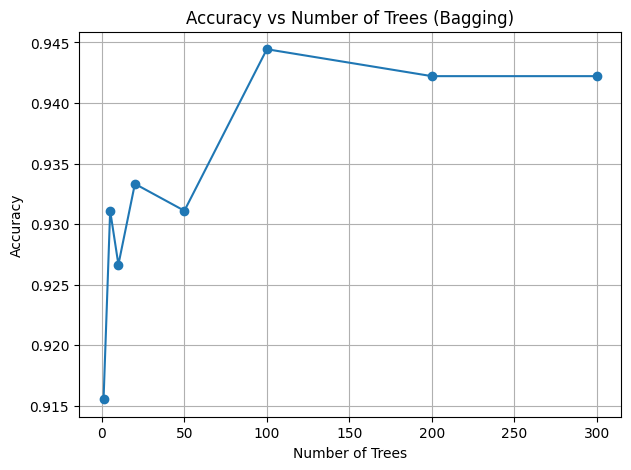

In [ ]:
# ============================================
# 4. ΟΠΤΙΚΟΠΟΙΗΣΗ ACCURACY vs NUMBER OF TREES
# ============================================

plt.figure(figsize=(7,5))
plt.plot(n_trees_list, accuracies, marker='o')
plt.title("Accuracy vs Number of Trees (Bagging)")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


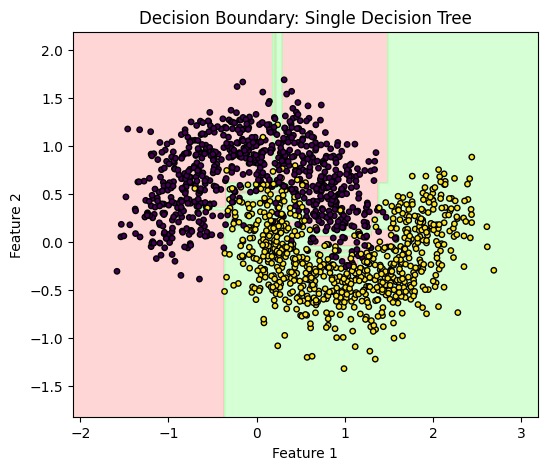

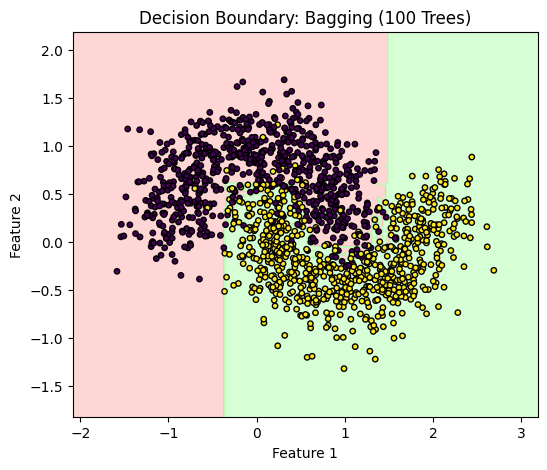

In [ ]:
# ============================================
# 6. DECISION BOUNDARIES ΓΙΑ DT ΚΑΙ BAGGING
# ============================================

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFBBBB','#BBFFBB']), alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=15, edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Decision Tree
plot_decision_boundary(dt, X, y, "Decision Boundary: Single Decision Tree")

# Bagging 100
plot_decision_boundary(bag100, X, y, "Decision Boundary: Bagging (100 Trees)")


In [ ]:
# ============================================
# 7. ΤΕΛΙΚΗ ΑΞΙΟΛΟΓΗΣΗ BAGGING 100 TREES
# ============================================

y_pred_bag = bag100.predict(X_test)

print("Bagging (100 trees) Accuracy:", accuracy_score(y_test, y_pred_bag))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bag))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))


Bagging (100 trees) Accuracy: 0.9444444444444444

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       234
           1       0.95      0.94      0.94       216

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450


Confusion Matrix:
 [[223  11]
 [ 14 202]]


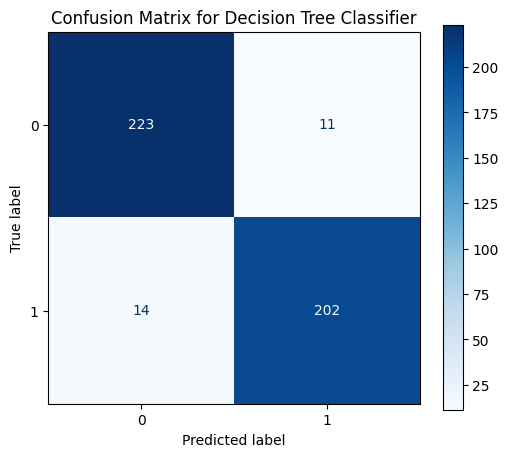

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Δημιουργία και εμφάνιση του Confusion Matrix για το Decision Tree
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(bag100, X_test, y_test, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Decision Tree Classifier")
plt.show()